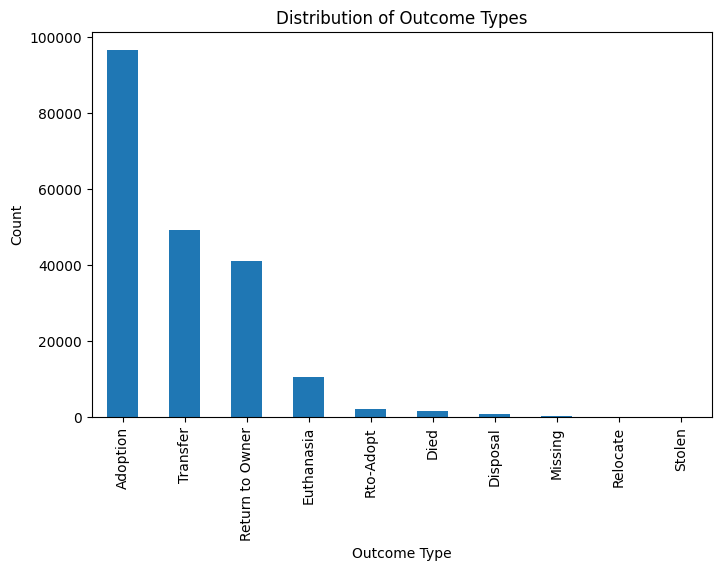

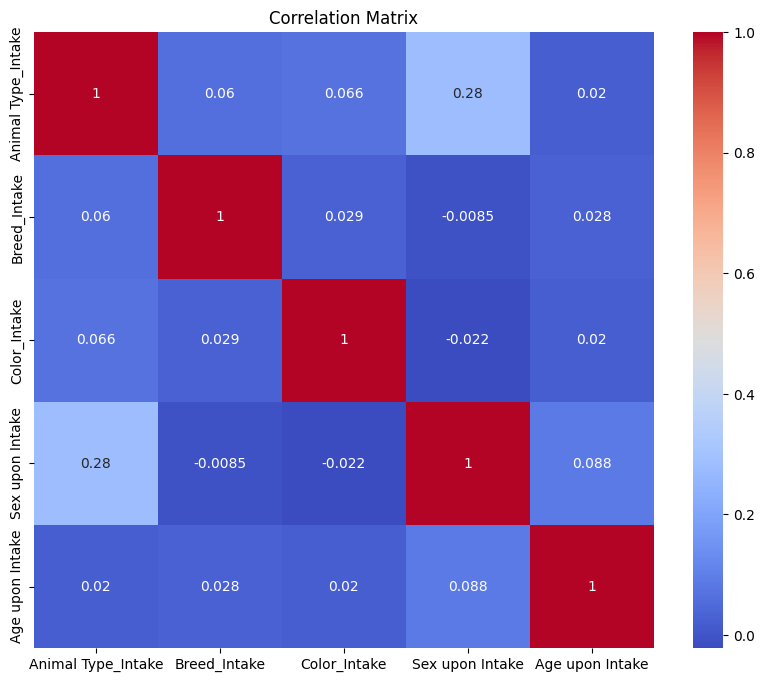

              precision    recall  f1-score   support

           0       0.63      0.75      0.68     19449
           1       0.16      0.04      0.06       303
           2       0.30      0.06      0.10       151
           3       0.73      0.53      0.61      1987
           4       0.43      0.12      0.19        25
           5       0.00      0.00      0.00         6
           6       0.54      0.51      0.52      8221
           7       0.06      0.02      0.03       374
           8       0.00      0.00      0.00         3
           9       0.51      0.39      0.44      9826

    accuracy                           0.59     40345
   macro avg       0.33      0.24      0.26     40345
weighted avg       0.57      0.59      0.57     40345



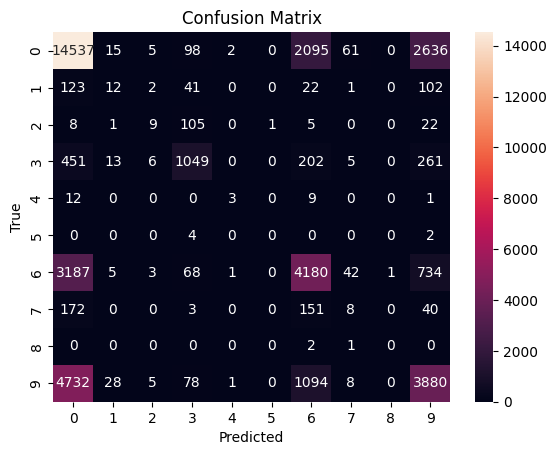

Outcome Prediction System: Predicts the likely outcome of animals based on intake features.
Adoption Priority Dashboard: Identifies animals at risk of prolonged stay to prioritize them.


C:\Users\joshi\AppData\Local\Temp\ipykernel_39328\819992901.py:87: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged_df['DateTime_Intake'] = pd.to_datetime(merged_df['DateTime_Intake'])


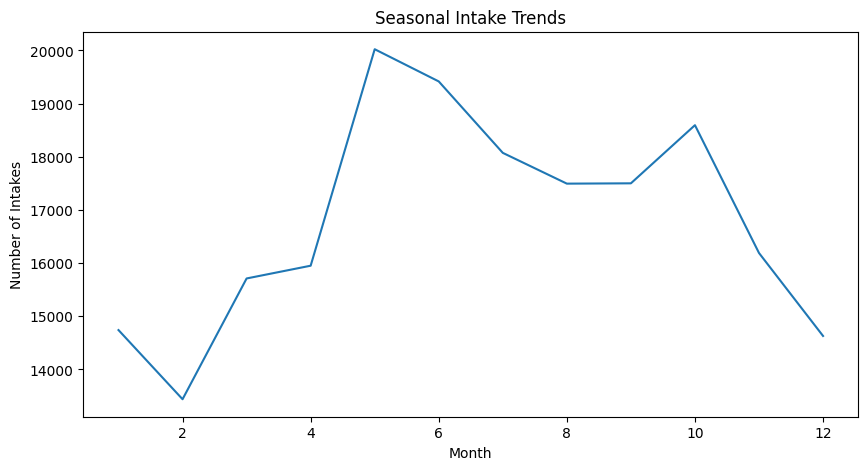

Accessibility: Ensure fair visibility for all animals regardless of breed or age.

Ethics: Transparent model explanations to avoid bias in adoption chances.

Equity: Prevent discrimination against certain animal types or breeds.

Privacy: Protect sensitive data regarding animal history.

Security: Implement robust security measures for shelter databases.

Sustainability: Efficient models to minimize computational resources.

Well-being: Focus AI on improving adoption rates and animal welfare.



In [6]:
# Project: PAW PETROL - Animal Shelter Outcome Prediction

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 2. Load Data
intakes_df = pd.read_csv('C:/Users/joshi/Downloads/Austin_Animal_Center_Intakes.csv', encoding='latin1')
outcomes_df = pd.read_csv('C:/Users/joshi/Downloads/Austin_Animal_Center_Outcomes.csv', encoding='latin1')


# 3. Data Preparation
## Merge datasets on Animal ID
merged_df = pd.merge(intakes_df, outcomes_df, on='Animal ID', suffixes=('_Intake', '_Outcome'))

## Select relevant features
selected_features = ['Animal Type_Intake', 'Breed_Intake', 'Color_Intake', 'Sex upon Intake', 'Age upon Intake', 'Outcome Type']
data = merged_df[selected_features]

## Handle missing values
data = data.dropna()

## Encode categorical variables
le = LabelEncoder()
for column in ['Animal Type_Intake', 'Breed_Intake', 'Color_Intake', 'Sex upon Intake', 'Age upon Intake']:
    data[column] = le.fit_transform(data[column])

X = data.drop('Outcome Type', axis=1)
y = data['Outcome Type']

# Encode target
y = le.fit_transform(y)

# 4. Data Visualization
## Outcome distribution
plt.figure(figsize=(8,5))
data['Outcome Type'].value_counts().plot(kind='bar')
plt.title('Distribution of Outcome Types')
plt.xlabel('Outcome Type')
plt.ylabel('Count')
plt.show()

# Select only numeric columns
numeric_data = data.select_dtypes(include=[np.number])

# Now plot correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


# 5. Predictive Modeling
## Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model training
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

## Predictions
y_pred = rf_model.predict(X_test)

## Evaluation
print(classification_report(y_test, y_pred))
conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 6. DSS-Based Solutions
## Outcome Prediction System
print("Outcome Prediction System: Predicts the likely outcome of animals based on intake features.")

## Adoption Priority Dashboard
print("Adoption Priority Dashboard: Identifies animals at risk of prolonged stay to prioritize them.")

## Seasonal Intake and Outcome Analysis
merged_df['DateTime_Intake'] = pd.to_datetime(merged_df['DateTime_Intake'])
merged_df['month'] = merged_df['DateTime_Intake'].dt.month

seasonal_intake = merged_df.groupby('month').size()

plt.figure(figsize=(10,5))
seasonal_intake.plot()
plt.title('Seasonal Intake Trends')
plt.xlabel('Month')
plt.ylabel('Number of Intakes')
plt.show()

# 7. Ethical and Operational Considerations
ethical_issues = {
    "Accessibility": "Ensure fair visibility for all animals regardless of breed or age.",
    "Ethics": "Transparent model explanations to avoid bias in adoption chances.",
    "Equity": "Prevent discrimination against certain animal types or breeds.",
    "Privacy": "Protect sensitive data regarding animal history.",
    "Security": "Implement robust security measures for shelter databases.",
    "Sustainability": "Efficient models to minimize computational resources.",
    "Well-being": "Focus AI on improving adoption rates and animal welfare."
}

for issue, solution in ethical_issues.items():
    print(f"{issue}: {solution}\n")


In [2]:
pip install xgboost


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/5e/03/15cd49e855c62226ecf1831bbe4c8e73a4324856077a23c495538a36e557/xgboost-3.0.0-py3-none-win_amd64.whl.metadata
  Obtaining dependency information for scipy from https://files.pythonhosted.org/packages/b9/8b/7ec1832b09dbc88f3db411f8cdd47db04505c4b72c99b11c920a8f0479c3/scipy-1.15.2-cp311-cp311-win_amd64.whl.metadata
  Using cached scipy-1.15.2-cp311-cp311-win_amd64.whl.metadata (60 kB)
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB 325.1 kB/s eta 0:07:42
   ---------------------------------------- 0.1/150.0 MB 1.1 MB/s eta 0:02:13
   ---------------------------------------- 0.4/150.0 MB 2.3 MB/s eta 0:01:06
   ---------------------------------------- 0.6/150.0 MB 3.1 MB/s eta 0:00:48
   ---------------------------------------- 1.0/150.0 MB 3.9 M

In [3]:
pip install scikit-learn


  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/a1/a6/c5b78606743a1f28eae8f11973de6613a5ee87366796583fb74c67d54939/scikit_learn-1.6.1-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for joblib>=1.2.0 from https://files.pythonhosted.org/packages/91/29/df4b9b42f2be0b623cbd5e2140cafcaa2bef0759a00b7b70104dcfe2fb51/joblib-1.4.2-py3-none-any.whl.metadata
  Obtaining dependency information for threadpoolctl>=3.1.0 from https://files.pythonhosted.org/packages/32/d5/f9a850d79b0851d1d4ef6456097579a9005b31fea68726a4ae5f2d82ddd9/threadpoolctl-3.6.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---------------------------------------- 0.1/11.1 MB 2.6 MB/s eta 0:00:05
   - -------------------------------------- 0.5/11.1 MB 6.7 MB/s eta 0:00:02
   --- ------------------------------------ 1.1/11.1 MB 8.6 MB/s eta 0:00:02
   ----- ---------------------------------- 1.7/11.1 MB 9.


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
pip install scikit-learn --upgrade


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
pip install seaborn

  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   ----- --------------------------------- 41.0/294.9 kB 487.6 kB/s eta 0:00:01
   -------------------------------------- - 286.7/294.9 kB 2.9 MB/s eta 0:00:01
   ---------------------------------------- 294.9/294.9 kB 2.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\Users\joshi\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:29:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.59      0.84      0.69     19449
           1       0.38      0.01      0.02       303
           2       0.73      0.05      0.10       151
           3       0.84      0.52      0.64      1987
           4       0.50      0.08      0.14        25
           5       0.00      0.00      0.00         6
           6       0.54      0.41      0.47      8221
           7       0.00      0.00      0.00       374
           8       0.00      0.00      0.00         3
           9       0.62      0.34      0.44      9826

    accuracy                           0.60     40345
   macro avg       0.42      0.23      0.25     40345
weighted avg       0.59      0.60      0.57     40345



c:\Users\joshi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\joshi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\joshi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

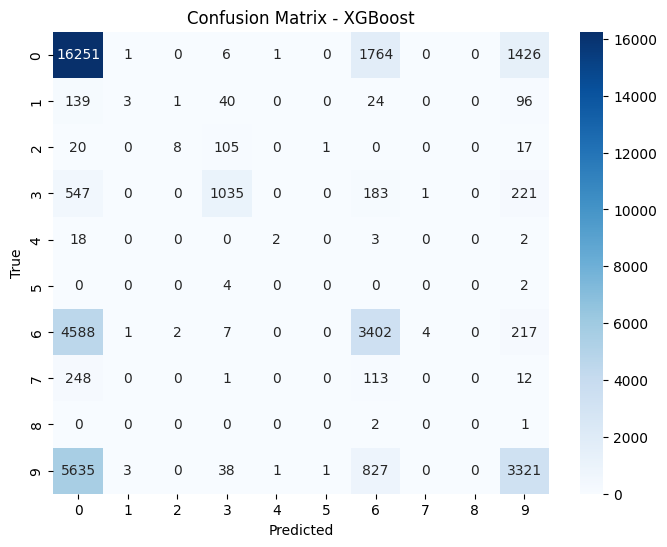

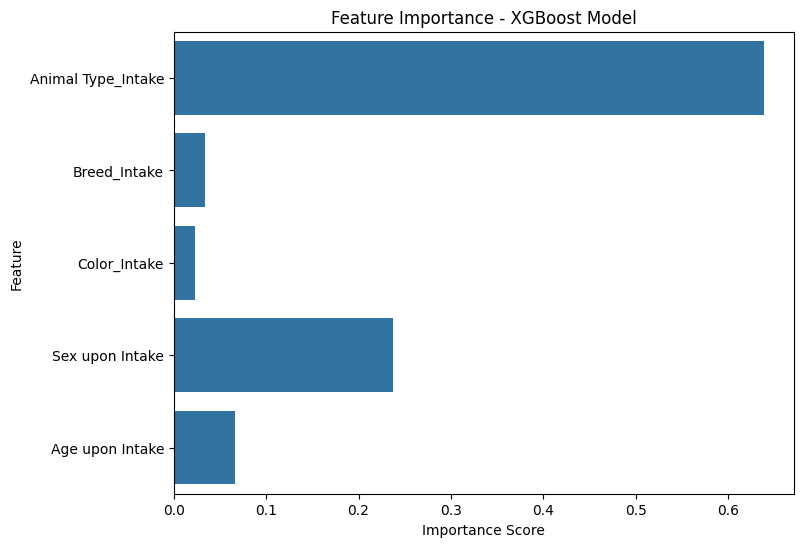


--- Ethical Analysis Table ---
Accessibility: Ensure visibility for animals with special needs and older pets.
Ethics: Be transparent about why adoption suggestions are made.
Equity: Avoid bias towards certain breeds or ages in predictions.
Privacy: Protect adopter and animal data (e.g., medical history).
Security: Secure all intake and adoption records properly.
Sustainability: Reduce unnecessary prolonged stays via better matching.
Well-being: Prioritize the health and happiness of animals over prediction accuracy alone.


In [3]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from xgboost import XGBClassifier

# 2. Load data
intakes_df = pd.read_csv('C:/Users/joshi/Downloads/Austin_Animal_Center_Intakes.csv', encoding='latin1')
outcomes_df = pd.read_csv('C:/Users/joshi/Downloads/Austin_Animal_Center_Outcomes.csv', encoding='latin1')

# 3. Merge datasets
merged_df = pd.merge(intakes_df, outcomes_df, on='Animal ID', suffixes=('_Intake', '_Outcome'))

# 4. Preprocessing
data = merged_df[['Animal Type_Intake', 'Breed_Intake', 'Color_Intake', 'Sex upon Intake', 'Age upon Intake', 'Outcome Type']]
data = data.dropna()

# Label Encoding
le = LabelEncoder()
for col in ['Animal Type_Intake', 'Breed_Intake', 'Color_Intake', 'Sex upon Intake', 'Age upon Intake']:
    data[col] = le.fit_transform(data[col])

# Define X and y
X = data.drop('Outcome Type', axis=1)
y = data['Outcome Type']
y = le.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Build XGBoost Model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)

# 6. Predictions
y_pred_xgb = xgb_model.predict(X_test)

# 7. Evaluation
print("Classification Report for XGBoost:")
print(classification_report(y_test, y_pred_xgb))

# 8. Confusion Matrix
conf_mat_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8,6))
sns.heatmap(conf_mat_xgb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 9. Feature Importance
importances = xgb_model.feature_importances_
feature_names = X.columns

# Plot
plt.figure(figsize=(8,6))
sns.barplot(x=importances, y=feature_names)
plt.title('Feature Importance - XGBoost Model')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

# 10. Ethical Considerations Table
ethical_issues = {
    "Accessibility": "Ensure visibility for animals with special needs and older pets.",
    "Ethics": "Be transparent about why adoption suggestions are made.",
    "Equity": "Avoid bias towards certain breeds or ages in predictions.",
    "Privacy": "Protect adopter and animal data (e.g., medical history).",
    "Security": "Secure all intake and adoption records properly.",
    "Sustainability": "Reduce unnecessary prolonged stays via better matching.",
    "Well-being": "Prioritize the health and happiness of animals over prediction accuracy alone."
}

print("\n--- Ethical Analysis Table ---")
for key, value in ethical_issues.items():
    print(f"{key}: {value}")


